In [3]:
import os
import re
from sklearn import tree
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns

pd.options.mode.chained_assignment

'warn'

In [4]:
df = pd.read_csv('/Users/ryan.oliveira/Desktop/puc/ppl-cd-pcd-sist-int-2025-1-grupo-5-2025-1/assets/data/State_of_data_BR_2023_original.csv')


In [5]:
colunas_codigo = ['P2_h', 'P4_d_1', 'P4_d_2', 'P4_d_3', 'P4_d_4', 'P4_d_5', 
                 'P4_d_6', 'P4_d_7', 'P4_d_8', 'P4_d_9', 'P4_d_10', 'P4_d_11', 
                 'P4_d_12', 'P4_d_13', 'P4_d_14', 'P4_d_15']

# Procurar strings que contêm os códigos desejados
colunas_selecionadas = []
for codigo in colunas_codigo:
    colunas_correspondentes = [col for col in df.columns if codigo in col]
    if colunas_correspondentes:
        colunas_selecionadas.extend(colunas_correspondentes)

# Criar o DataFrame com as colunas selecionadas
df_atributos_selecionados = df[colunas_selecionadas]

df_atributos_selecionados.columns

Index(['('P2_h ', 'Faixa salarial')', '('P4_d_1 ', 'SQL')',
       '('P4_d_10 ', 'Scala')', '('P4_d_11 ', 'Matlab')',
       '('P4_d_12 ', 'Rust')', '('P4_d_13 ', 'PHP')',
       '('P4_d_14 ', 'JavaScript')',
       '('P4_d_15 ', 'Não utilizo nenhuma linguagem')', '('P4_d_2 ', 'R ')',
       '('P4_d_3 ', 'Python')', '('P4_d_4 ', 'C/C++/C#')',
       '('P4_d_5 ', '.NET')', '('P4_d_6 ', 'Java')', '('P4_d_7 ', 'Julia')',
       '('P4_d_8 ', 'SAS/Stata')', '('P4_d_9 ', 'Visual Basic/VBA')',
       '('P4_d_10 ', 'Scala')', '('P4_d_11 ', 'Matlab')',
       '('P4_d_12 ', 'Rust')', '('P4_d_13 ', 'PHP')',
       '('P4_d_14 ', 'JavaScript')',
       '('P4_d_15 ', 'Não utilizo nenhuma linguagem')'],
      dtype='object')

In [6]:
df_novo = df_atributos_selecionados.copy()

df_novo.rename(
    columns={ 
        "('P2_h ', 'Faixa salarial')": "faixa_salarial",
        "('P4_d_1 ', 'SQL')": "sql",
        "('P4_d_2 ', 'R ')": "r",
        "('P4_d_3 ', 'Python')": "python",
        "('P4_d_4 ', 'C/C++/C#')": "c_cpp_csharp",
        "('P4_d_5 ', '.NET')": "dotnet",
        "('P4_d_6 ', 'Java')": "java",
        "('P4_d_7 ', 'Julia')": "julia",
        "('P4_d_8 ', 'SAS/Stata')": "sas_stata",
        "('P4_d_9 ', 'Visual Basic/VBA')": "vb_vba",
        "('P4_d_10 ', 'Scala')": "scala",
        "('P4_d_11 ', 'Matlab')": "matlab",
        "('P4_d_12 ', 'Rust')": "rust",
        "('P4_d_13 ', 'PHP')": "php",
        "('P4_d_14 ', 'JavaScript')": "javascript",
        "('P4_d_15 ', 'Não utilizo nenhuma linguagem')": "nao_utiliza_linguagem"
        },
    inplace=True
)

In [7]:
df_novo.columns

Index(['faixa_salarial', 'sql', 'scala', 'matlab', 'rust', 'php', 'javascript',
       'nao_utiliza_linguagem', 'r', 'python', 'c_cpp_csharp', 'dotnet',
       'java', 'julia', 'sas_stata', 'vb_vba', 'scala', 'matlab', 'rust',
       'php', 'javascript', 'nao_utiliza_linguagem'],
      dtype='object')

In [8]:
colunas_linguagem = ['sql', 'scala', 'matlab', 'rust', 'php', 'javascript', 'nao_utiliza_linguagem', 
           'r', 'python', 'c_cpp_csharp', 'dotnet', 'java', 'julia', 'sas_stata', 'vb_vba']

# Preencher NaN com 0 em cada coluna
for coluna in colunas_linguagem:
    if coluna in df_novo.columns:
        df_novo[coluna] = df_novo[coluna].fillna(0)

In [9]:
df_novo.columns

Index(['faixa_salarial', 'sql', 'scala', 'matlab', 'rust', 'php', 'javascript',
       'nao_utiliza_linguagem', 'r', 'python', 'c_cpp_csharp', 'dotnet',
       'java', 'julia', 'sas_stata', 'vb_vba', 'scala', 'matlab', 'rust',
       'php', 'javascript', 'nao_utiliza_linguagem'],
      dtype='object')

In [10]:
df_novo = df_novo.loc[:, ~df_novo.columns.duplicated()]

In [11]:
num_nulos = df_novo['faixa_salarial'].isnull().sum()
print(f"Número de valores nulos em 'faixa salarial': {num_nulos}")

Número de valores nulos em 'faixa salarial': 540


In [12]:
proporcao_nulos = num_nulos / len(df_novo)
print(f"Proporção de valores nulos: {proporcao_nulos:.2%}")

Proporção de valores nulos: 10.20%


In [13]:
nulos_df = df_novo[df_novo['faixa_salarial'].isnull()]
print(nulos_df.describe())

         sql  scala  matlab   rust    php  javascript  nao_utiliza_linguagem  \
count  540.0  540.0   540.0  540.0  540.0       540.0                  540.0   
mean     0.0    0.0     0.0    0.0    0.0         0.0                    0.0   
std      0.0    0.0     0.0    0.0    0.0         0.0                    0.0   
min      0.0    0.0     0.0    0.0    0.0         0.0                    0.0   
25%      0.0    0.0     0.0    0.0    0.0         0.0                    0.0   
50%      0.0    0.0     0.0    0.0    0.0         0.0                    0.0   
75%      0.0    0.0     0.0    0.0    0.0         0.0                    0.0   
max      0.0    0.0     0.0    0.0    0.0         0.0                    0.0   

           r  python  c_cpp_csharp  dotnet   java  julia  sas_stata  vb_vba  
count  540.0   540.0         540.0   540.0  540.0  540.0      540.0   540.0  
mean     0.0     0.0           0.0     0.0    0.0    0.0        0.0     0.0  
std      0.0     0.0           0.0     0.0   

In [14]:
# Remover linhas onde 'faixa_salarial' é nula
df_novo = df_novo.dropna(subset=['faixa_salarial'])

In [15]:
df_novo.isna().sum()

faixa_salarial           0
sql                      0
scala                    0
matlab                   0
rust                     0
php                      0
javascript               0
nao_utiliza_linguagem    0
r                        0
python                   0
c_cpp_csharp             0
dotnet                   0
java                     0
julia                    0
sas_stata                0
vb_vba                   0
dtype: int64

In [16]:
unique_values = df_novo['faixa_salarial'].unique()
print(unique_values)

['de R$ 12.001/mês a R$ 16.000/mês' 'de R$ 6.001/mês a R$ 8.000/mês'
 'de R$ 4.001/mês a R$ 6.000/mês' 'de R$ 8.001/mês a R$ 12.000/mês'
 'de R$ 20.001/mês a R$ 25.000/mês' 'de R$ 1.001/mês a R$ 2.000/mês'
 'de R$ 3.001/mês a R$ 4.000/mês' 'de R$ 16.001/mês a R$ 20.000/mês'
 'de R$ 2.001/mês a R$ 3.000/mês' 'Acima de R$ 40.001/mês'
 'de R$ 25.001/mês a R$ 30.000/mês' 'Menos de R$ 1.000/mês'
 'de R$ 30.001/mês a R$ 40.000/mês' 'de R$ 101/mês a R$ 2.000/mês']


In [17]:
value_counts = df_novo['faixa_salarial'].value_counts()
print(value_counts)

faixa_salarial
de R$ 8.001/mês a R$ 12.000/mês     1026
de R$ 4.001/mês a R$ 6.000/mês       745
de R$ 12.001/mês a R$ 16.000/mês     650
de R$ 6.001/mês a R$ 8.000/mês       637
de R$ 3.001/mês a R$ 4.000/mês       352
de R$ 16.001/mês a R$ 20.000/mês     328
de R$ 2.001/mês a R$ 3.000/mês       288
de R$ 1.001/mês a R$ 2.000/mês       215
de R$ 20.001/mês a R$ 25.000/mês     195
de R$ 25.001/mês a R$ 30.000/mês     128
de R$ 30.001/mês a R$ 40.000/mês      86
Acima de R$ 40.001/mês                72
Menos de R$ 1.000/mês                 30
de R$ 101/mês a R$ 2.000/mês           1
Name: count, dtype: int64


In [18]:
df_novo# Removendo a coluna 'faixa_salarial_numerica'
df_novo = df_novo.drop('faixa_salarial_numerica', axis=1)

# Verificando se a coluna foi removida
print(df_novo.head())

KeyError: "['faixa_salarial_numerica'] not found in axis"

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

y = df_novo['faixa_salarial']
X = df_novo.drop('faixa_salarial', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_test_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Fazer previsões no conjunto de treinamento
y_train_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

print("Acurácia no conjunto de teste:", test_accuracy)
print("Acurácia no conjunto de treinamento:", train_accuracy)

Acurácia no conjunto de teste: 0.22555205047318613
Acurácia no conjunto de treinamento: 0.2714836899333567


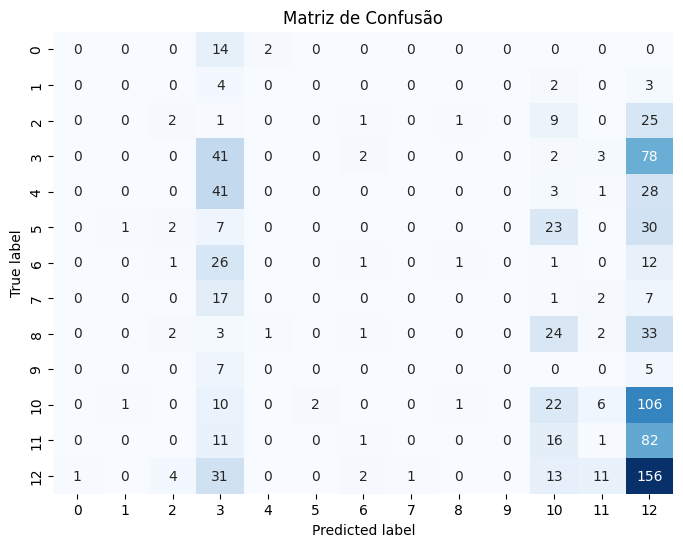

In [55]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Matriz de Confusão')
plt.show()

In [49]:
classes = ['Acima de R$ 40.001/mês', 'Menos de R$ 1.000/mês',
           'de R$ 1.001/mês a R$ 2.000/mês', 'de R$ 101/mês a R$ 2.000/mês',
           'de R$ 12.001/mês a R$ 16.000/mês', 'de R$ 16.001/mês a R$ 20.000/mês',
           'de R$ 2.001/mês a R$ 3.000/mês', 'de R$ 20.001/mês a R$ 25.000/mês',
           'de R$ 25.001/mês a R$ 30.000/mês', 'de R$ 3.001/mês a R$ 4.000/mês',
           'de R$ 30.001/mês a R$ 40.000/mês', 'de R$ 4.001/mês a R$ 6.000/mês',
           'de R$ 6.001/mês a R$ 8.000/mês', 'de R$ 8.001/mês a R$ 12.000/mês']

for i, class_name in enumerate(classes):
    print(f"Classe {i}: {class_name}")

Classe 0: Acima de R$ 40.001/mês
Classe 1: Menos de R$ 1.000/mês
Classe 2: de R$ 1.001/mês a R$ 2.000/mês
Classe 3: de R$ 101/mês a R$ 2.000/mês
Classe 4: de R$ 12.001/mês a R$ 16.000/mês
Classe 5: de R$ 16.001/mês a R$ 20.000/mês
Classe 6: de R$ 2.001/mês a R$ 3.000/mês
Classe 7: de R$ 20.001/mês a R$ 25.000/mês
Classe 8: de R$ 25.001/mês a R$ 30.000/mês
Classe 9: de R$ 3.001/mês a R$ 4.000/mês
Classe 10: de R$ 30.001/mês a R$ 40.000/mês
Classe 11: de R$ 4.001/mês a R$ 6.000/mês
Classe 12: de R$ 6.001/mês a R$ 8.000/mês
Classe 13: de R$ 8.001/mês a R$ 12.000/mês


In [57]:
from collections import Counter

class_counts = Counter(y_train)
print("Distribuição das classes no conjunto de treinamento:", class_counts)

Distribuição das classes no conjunto de treinamento: Counter({'de R$ 8.001/mês a R$ 12.000/mês': 807, 'de R$ 4.001/mês a R$ 6.000/mês': 597, 'de R$ 6.001/mês a R$ 8.000/mês': 526, 'de R$ 12.001/mês a R$ 16.000/mês': 524, 'de R$ 3.001/mês a R$ 4.000/mês': 286, 'de R$ 16.001/mês a R$ 20.000/mês': 255, 'de R$ 2.001/mês a R$ 3.000/mês': 225, 'de R$ 1.001/mês a R$ 2.000/mês': 176, 'de R$ 20.001/mês a R$ 25.000/mês': 153, 'de R$ 25.001/mês a R$ 30.000/mês': 101, 'de R$ 30.001/mês a R$ 40.000/mês': 74, 'Acima de R$ 40.001/mês': 56, 'Menos de R$ 1.000/mês': 21, 'de R$ 101/mês a R$ 2.000/mês': 1})


In [61]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],   # Número de árvores na floresta
    'max_depth': [None, 10, 20, 30],  # Profundidade máxima da árvore
    'min_samples_split': [2, 5, 10],  # Número mínimo de amostras necessárias para dividir um nó
    'min_samples_leaf': [1, 2, 4]     # Número mínimo de amostras em um nó folha
}

In [62]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,  # Validação cruzada com 5 dobras
    n_jobs=-1,  # Usar todos os núcleos de CPU disponíveis
    verbose=2
)

In [104]:
def group_salaries(salary):
    if salary in ['de R$ 1.001/mês a R$ 2.000/mês', 
                  'de R$ 2.001/mês a R$ 3.000/mês',
                  'de R$ 3.001/mês a R$ 4.000/mês']:
        return 'Baixo (até R$ 4.000)'
    elif salary in ['de R$ 4.001/mês a R$ 6.000/mês',
                    'de R$ 6.001/mês a R$ 8.000/mês']:
        return 'Médio (R$ 4.001 a R$ 8.000)'
    elif salary in ['de R$ 8.001/mês a R$ 12.000/mês',
                    'de R$ 12.001/mês a R$ 16.000/mês']:
        return 'Alto (R$ 8.001 a R$ 16.000)'
    else:
        return 'Muito Alto (acima de R$ 16.000)'

In [105]:
from imblearn.over_sampling import SMOTE 

classes_para_remover = ["Menos de R$ 1.000/mês", "de R$ 101/mês a R$ 2.000/mês"]
df_filtered = df_novo[~df_novo['faixa_salarial'].isin(classes_para_remover)]

df_filtered['faixa_salarial_agrupada'] = df_filtered['faixa_salarial'].apply(group_salaries)

y_filtered = df_filtered['faixa_salarial_agrupada']
X_filtered = df_filtered.drop(['faixa_salarial', 'faixa_salarial_agrupada'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.4, random_state=42)

# SMOTE
smote = SMOTE(
    random_state=42,
    sampling_strategy='auto',
    k_neighbors=5 
)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Grid Search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_resampled, y_train_resampled)

# Melhor modelo
best_model = grid_search.best_estimator_

y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

y_train_pred = best_model.predict(X_train_resampled)
train_accuracy = accuracy_score(y_train_resampled, y_train_pred)

/var/folders/p1/vrkk65316532v7sjv657d7pc0000gq/T/ipykernel_9142/196301911.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['faixa_salarial_agrupada'] = df_filtered['faixa_salarial'].apply(group_salaries)


Fitting 5 folds for each of 1296 candidates, totalling 6480 fits
[CV] END class_weight=balanced, max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.5s
[CV] END class_weight=balanced, max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.5s
[CV] END class_weight=balanced, max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.5s
[CV] END class_weight=balanced, max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.5s
[CV] END class_weight=balanced, max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.5s
[CV] END class_weight=balanced, max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time=   1.1s
[CV] END class_weight=balanced, max_depth=10, max_features=sqrt, min_samples_

In [106]:
print("\nMelhores hiperparâmetros:", grid_search.best_params_)
print("Acurácia no conjunto de teste:", test_accuracy)
print("Acurácia no conjunto de treinamento:", train_accuracy)


Melhores hiperparâmetros: {'class_weight': 'balanced', 'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
Acurácia no conjunto de teste: 0.393859184753838
Acurácia no conjunto de treinamento: 0.45478983382209187


In [107]:
from sklearn.metrics import classification_report
print("\nRelatório de classificação:")
print(classification_report(y_test, y_test_pred))


Relatório de classificação:
                                 precision    recall  f1-score   support

    Alto (R$ 8.001 a R$ 16.000)       0.47      0.15      0.23       653
           Baixo (até R$ 4.000)       0.37      0.45      0.41       385
Muito Alto (acima de R$ 16.000)       0.47      0.67      0.55       310
    Médio (R$ 4.001 a R$ 8.000)       0.35      0.48      0.40       541

                       accuracy                           0.39      1889
                      macro avg       0.41      0.44      0.40      1889
                   weighted avg       0.41      0.39      0.37      1889



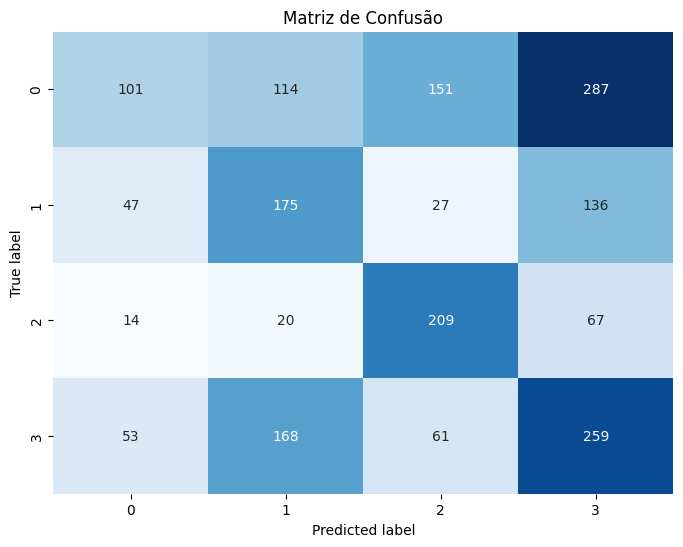

In [108]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Matriz de Confusão')
plt.show()